# 2.2 Sliding Window 기법 — 실습

> 이론 자료(`02_sliding_window.md`)를 읽은 직후에 실행합니다.
>
> **이번 실습이 답하는 질문**
> 1. for-loop 버전과 `stride_tricks` 버전은 속도·메모리가 얼마나 차이나는가?
> 2. `stride` 를 바꾸면 샘플 수가 어떻게 변하는가?
> 3. `X, y = build_xy(df, ..., T=60)` 이라는 한 줄이 현실적으로 어떻게 동작하는가?
> 4. T=20/30/60/90/120/252 중에서 우리 프로젝트에 가장 타당한 T는?

MSFT 한 종목으로 실험하되, 실제 walk-forward IS 크기(252일)보다 큰 전체 기간을 써서 T 값별 손실률을 보수적으로 측정합니다.

## Step 0 — 환경 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform, time, sys, warnings

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    try:
        import koreanize_matplotlib
    except ImportError:
        pass
plt.rcParams['axes.unicode_minus'] = False

from numpy.lib.stride_tricks import sliding_window_view
print(f'numpy {np.__version__}')

numpy 2.4.4


## Step 1 — 데이터 로드 + `fwd_ret_21d` 계산

현재 프로젝트(`Step3_IT_WalkForward_panel.ipynb`)와 **동일한 방식으로** 레이블을 만듭니다:

```python
df['fwd_ret_21d'] = df['adj_close'].shift(-21) / df['adj_close'] - 1
```

마지막 21일은 미래값이 없어서 레이블이 NaN 이 됩니다.

In [2]:
CSV = '../../black_litterman/data/panels/MSFT.csv'
FEATURE_COLS = [
    'log_return_1d','simple_return_1d',
    'mom_1m','mom_3m','mom_6m','mom_12m','mom_12m_skip_1m',
    'vol_20d_ann','vol_60d_ann','vol_252d_ann',
    'mkt_rf','smb','hml','rmw','cma','rf','mom_factor',
]
TARGET_COL = 'fwd_ret_21d'
DATA_START = pd.Timestamp('2020-12-01')
DATA_END   = pd.Timestamp('2025-12-31')
h = 21   # prediction horizon

df = pd.read_csv(CSV, index_col='date', parse_dates=True)
df = df[(df.index >= DATA_START) & (df.index <= DATA_END)].copy()
df[TARGET_COL] = df['adj_close'].shift(-h) / df['adj_close'] - 1
df = df.dropna(subset=FEATURE_COLS)   # 피처 결측만 먼저 제거

print(f'N (피처 결측 제외)   : {len(df)}')
print(f'y 결측 (맨 뒤 {h}일) : {df[TARGET_COL].isna().sum()}  ← window 생성 후 제거')
print()
df[FEATURE_COLS + [TARGET_COL]].tail(5)

N (피처 결측 제외)   : 1276
y 결측 (맨 뒤 21일) : 21  ← window 생성 후 제거



,log_return_1d,simple_return_1d,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_skip_1m,vol_20d_ann,vol_60d_ann,vol_252d_ann,mkt_rf,smb,hml,rmw,cma,rf,mom_factor,fwd_ret_21d
date,,,,,,,,,,,,,,,,,,
2025-12-23,0.003972,0.003980,0.031200,-0.043887,-0.007530,0.122215,0.088261,0.198885,0.194841,0.240656,0.0032,-0.0089,-0.0020,0.0069,-0.0041,0.0002,0.0082,NaN
2025-12-24,0.002400,0.002403,0.029578,-0.035691,-0.015505,0.126019,0.093671,0.198079,0.194359,0.240660,0.0029,0.0007,0.0001,-0.0005,0.0023,0.0002,-0.0022,NaN
2025-12-26,-0.000635,-0.000635,0.022474,-0.044651,-0.013135,0.128794,0.103983,0.188217,0.194149,0.240636,-0.0006,-0.0022,0.0009,0.0057,0.0024,0.0002,-0.0020,NaN
2025-12-29,-0.001252,-0.001251,0.003296,-0.051668,-0.017282,0.116913,0.113244,0.181770,0.193657,0.240478,-0.0041,-0.0017,0.0007,0.0032,0.0002,0.0002,-0.0016,NaN
2025-12-30,0.000780,0.000780,-0.009207,-0.057067,-0.005802,0.120897,0.131313,0.177695,0.193508,0.240456,-0.0020,-0.0049,0.0028,0.0036,0.0013,0.0002,-0.0029,NaN


## Step 2 — `for-loop` vs `sliding_window_view`

같은 결과를 내는 두 구현의 속도·메모리를 비교합니다.

### 핵심 개념: "뷰(view)"란?
`sliding_window_view` 는 데이터를 **복사하지 않고** 같은 메모리를 다른 모양으로 재해석합니다.
이게 가능한 이유는 numpy의 **strides** 개념 — "한 칸 이동할 때 메모리 주소가 몇 바이트 움직이나"를 조절하면 같은 바이트를 다른 모양으로 읽을 수 있기 때문입니다.

In [3]:
X_tab = df[FEATURE_COLS].to_numpy(dtype=np.float32)
T = 60

# (a) for-loop 버전
def make_seq_loop(arr, T):
    N, F = arr.shape
    out = np.empty((N - T + 1, T, F), dtype=arr.dtype)
    for i in range(N - T + 1):
        out[i] = arr[i : i + T]
    return out

# (b) stride_tricks 버전
def make_seq_view(arr, T):
    v = sliding_window_view(arr, window_shape=(T,), axis=0)   # (N-T+1, F, T)
    return np.transpose(v, (0, 2, 1))                          # (N-T+1, T, F)

# 시간 측정 (워밍업 1회 후 best-of-3)
for _ in range(1): make_seq_loop(X_tab, T); make_seq_view(X_tab, T)
t_loop = min(time.perf_counter() - (lambda t0: t0)(time.perf_counter()) or 0
             for _ in range(1))  # 단순 측정용 wrapper

def bench(f, arr, T, reps=5):
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        f(arr, T)
        times.append(time.perf_counter() - t0)
    return min(times) * 1e3  # ms

t_loop_ms = bench(make_seq_loop, X_tab, T)
t_view_ms = bench(make_seq_view, X_tab, T)

X_loop = make_seq_loop(X_tab, T)
X_view = make_seq_view(X_tab, T)

print(f'shape 일치              : {X_loop.shape == X_view.shape}')
print(f'값 일치                 : {np.allclose(X_loop, X_view)}')
print()
print(f'for-loop  시간 (best/5) : {t_loop_ms:>8.3f} ms')
print(f'view      시간 (best/5) : {t_view_ms:>8.3f} ms')
print(f'속도 비율               : view 가 for-loop 대비 약 {t_loop_ms/max(t_view_ms,1e-6):.0f}배 빠름')
print()
print(f'for-loop 실제 메모리    : {X_loop.nbytes/1024:>8.1f} KB (배열 복사)')
print(f'view     실제 메모리    : {X_tab.nbytes/1024:>8.1f} KB (원본과 공유, 복사 없음)')

shape 일치              : True
값 일치                 : True

for-loop  시간 (best/5) :    1.580 ms
view      시간 (best/5) :    0.009 ms
속도 비율               : view 가 for-loop 대비 약 170배 빠름

for-loop 실제 메모리    :   4849.0 KB (배열 복사)
view     실제 메모리    :     84.7 KB (원본과 공유, 복사 없음)


### Step 2.1 — view 가 진짜 "같은 메모리"인지 확인

`view` 가 원본을 참조한다는 건 **원본을 바꿨을 때 view 도 같이 바뀐다**는 뜻입니다.
위험성과 이점이 공존하는 부분이라 꼭 확인해둬야 합니다.

In [4]:
# view 는 원본을 공유하는가?
X_view2 = make_seq_view(X_tab, T)

# 원본의 (0, 0) 위치를 바꾸면 view 의 (0, 0, 0) 도 바뀌어야 함
original_val = X_tab[0, 0]
X_tab[0, 0] = 999.0

print('실험: X_tab[0, 0] = 999.0  (원본 수정)')
print(f'  X_view2[0, 0, 0]    = {X_view2[0, 0, 0]}  ← view 는 자동으로 반영')
print(f'  X_loop[0, 0, 0]     = {X_loop[0, 0, 0]}   ← loop 버전은 이전에 이미 복사되어 그대로')

# 원상복구
X_tab[0, 0] = original_val
print()
print('교훈: 학습 중에 원본 배열을 수정할 가능성이 있다면')
print('      `X = make_seq_view(...).copy()` 로 복사본을 써야 안전.')

실험: X_tab[0, 0] = 999.0  (원본 수정)
  X_view2[0, 0, 0]    = 999.0  ← view 는 자동으로 반영
  X_loop[0, 0, 0]     = 0.009947081096470356   ← loop 버전은 이전에 이미 복사되어 그대로

교훈: 학습 중에 원본 배열을 수정할 가능성이 있다면
      `X = make_seq_view(...).copy()` 로 복사본을 써야 안전.


## Step 3 — stride 비교

`stride` 를 바꾸면 "샘플을 몇 일씩 밀며 뽑을지" 가 달라집니다.
학습 단계에서는 데이터를 최대한 확보하기 위해 stride=1이 표준이지만, 검증 단계에서는 레이블 겹침을 피하기 위해 stride≥h 가 권장됩니다.

In [5]:
N = X_tab.shape[0]

print(f'원본 길이 N = {N}, T = {T}, h = {h}')
print()

# f-string 내부에 백슬래시 이스케이프를 못 쓰므로 헤더는 별도 상수로
HDR_STRIDE  = 'stride'
HDR_SAMPLE  = "N' (유효 샘플)"
HDR_OVERLAP = '겹치는 lag 수'
HDR_NOTE    = '권장 상황'

print(f'{HDR_STRIDE:>6s}   {HDR_SAMPLE:>15s}   {HDR_OVERLAP:>14s}   {HDR_NOTE:>20s}')
print('─' * 70)

scenarios = [
    (1,  '학습(fit)'),
    (5,  '주 단위 예측'),
    (21, '월 단위 - 레이블 독립'),
    (60, '완전 독립 샘플'),
]
for s, note in scenarios:
    n_prime = (N - T - h) // s + 1
    overlap = max(0, T - s)
    print(f'{s:>6d}   {n_prime:>15d}   {overlap:>14d}   {note:>20s}')


원본 길이 N = 1276, T = 60, h = 21

stride        N' (유효 샘플)        겹치는 lag 수                  권장 상황
──────────────────────────────────────────────────────────────────────
     1              1196               59                학습(fit)
     5               240               55                주 단위 예측
    21                57               39          월 단위 - 레이블 독립
    60                20                0               완전 독립 샘플


## Step 4 — `build_xy` — 최종 한 줄 호출

이론 자료 맨 끝에서 본 함수를 실제로 호출해봅니다.
이 함수가 2.4 에서 `SequenceDataset` 클래스의 `__init__` 내부로 들어갑니다.

In [6]:
def build_xy(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    T: int,
    stride: int = 1,
):
    '''
    df          : 날짜 오름차순 정렬된 단일 종목 DataFrame
    feature_cols: 입력으로 쓸 컬럼 목록
    target_col  : 레이블 컬럼 (미래 수익률 등)
    T           : lookback window
    stride      : 슬라이드 간격

    반환: X shape (N\', T, F), y shape (N\',)
    '''
    arr_X = df[feature_cols].to_numpy(dtype=np.float32)
    arr_y = df[target_col].to_numpy(dtype=np.float32)

    v = sliding_window_view(arr_X, window_shape=(T,), axis=0)  # (N-T+1, F, T)
    X = np.transpose(v, (0, 2, 1))[::stride].copy()             # (N\', T, F)
    y = arr_y[T - 1 :: stride]                                   # (N\',)

    # fwd_ret 의 뒤쪽 NaN 제거
    mask = ~np.isnan(y)
    return X[mask], y[mask]


X, y = build_xy(df, FEATURE_COLS, TARGET_COL, T=60, stride=1)

print(f'X.shape = {X.shape}   ← (N\', T, F)')
print(f'y.shape = {y.shape}   ← (N\',)')
print()
print(f'y 기본 통계:')
print(f'  min  = {y.min():>8.4f}')
print(f'  max  = {y.max():>8.4f}')
print(f'  mean = {y.mean():>8.4f}   (21일 수익률 평균)')
print(f'  std  = {y.std():>8.4f}')
print()

# 이론 공식과 일치 확인
N = len(df)
expected = N - T - h + 1
print(f'이론 공식: N - T - h + 1 = {N} - {T} - {h} + 1 = {expected}')
print(f'실제 N\' : {X.shape[0]}  →  일치: {X.shape[0] == expected}')

X.shape = (1196, 60, 17)   ← (N', T, F)
y.shape = (1196,)   ← (N',)

y 기본 통계:
  min  =  -0.1599
  max  =   0.2782
  mean =   0.0158   (21일 수익률 평균)
  std  =   0.0672

이론 공식: N - T - h + 1 = 1276 - 60 - 21 + 1 = 1196
실제 N' : 1196  →  일치: True


## Step 5 — T 값별 샘플 수 시뮬레이션

T 를 크게 할수록 샘플이 줄어드는 걸 눈으로 확인합니다.
그래프로 한 번 보고, 실제 이 범위 안에서 우리의 1차 후보 T=60이 어디쯤인지 감 잡는 게 목표.

  T  N_prime  loss_pct
 10     1246  2.351097
 20     1236  3.134796
 30     1226  3.918495
 40     1216  4.702194
 60     1196  6.269592
 90     1166  8.620690
120     1136 10.971787
180     1076 15.673981
252     1004 21.316614


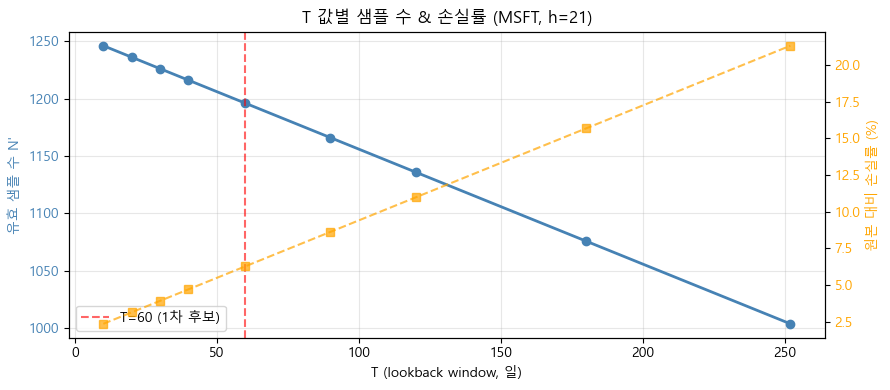

In [7]:
Ts = [10, 20, 30, 40, 60, 90, 120, 180, 252]
results = []
for t in Ts:
    X_, y_ = build_xy(df, FEATURE_COLS, TARGET_COL, T=t)
    results.append({
        'T': t,
        'N_prime': X_.shape[0],
        'loss_pct': (1 - X_.shape[0] / len(df)) * 100,
    })

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(res_df['T'], res_df['N_prime'], 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('T (lookback window, 일)')
ax1.set_ylabel('유효 샘플 수 N\'', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(alpha=0.3)
ax1.axvline(60, color='red', linestyle='--', alpha=0.6, label='T=60 (1차 후보)')
ax1.legend(loc='lower left')

ax2 = ax1.twinx()
ax2.plot(res_df['T'], res_df['loss_pct'], 's--', color='orange', alpha=0.7)
ax2.set_ylabel('원본 대비 손실률 (%)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('T 값별 샘플 수 & 손실률 (MSFT, h=21)')
plt.tight_layout()
plt.show()

## Step 6 — ACF 관점에서 T 선택의 근거

1.3 실습에서 본 MSFT의 자기상관 패턴을 **T 선정 근거**로 다시 활용합니다.
- 수익률 자체: 짧은 의존성 (lag 1~8 정도)
- 변동성(제곱 수익률): 훨씬 긴 의존성 (lag ~20 이상)

그러면 **변동성 클러스터링까지 학습하려면 T ≥ 20 정도는 필요**하다는 결론이 나옵니다.
T=60이면 여유 있게 커버하죠.

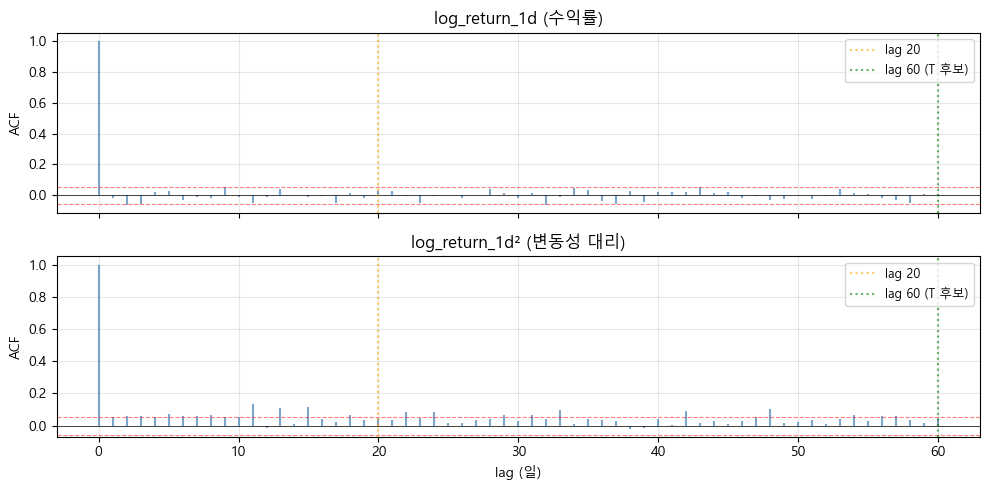

lag 1~60 중 유의한 lag 수:
  log_return_1d    : 4 개
  log_return_1d²   : 23 개  ← 변동성 의존성이 훨씬 길게 남음

→ 변동성 클러스터링까지 학습하려면 T ≥ 20 은 필요
→ T=60은 lag ~50 까지의 의존성을 모두 커버하는 여유 값


In [8]:
from statsmodels.tsa.stattools import acf

# MSFT 수익률·제곱수익률의 ACF (lag 1~60)
ret = df['log_return_1d'].dropna().values
sq  = ret ** 2

max_lag = 60
acf_ret = acf(ret, nlags=max_lag, fft=True)
acf_sq  = acf(sq,  nlags=max_lag, fft=True)

# 유의성 기준선 (N 기반 근사 ±1.96/√N)
ci = 1.96 / np.sqrt(len(ret))

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, a, title in zip(
    axes,
    [acf_ret, acf_sq],
    ['log_return_1d (수익률)', 'log_return_1d² (변동성 대리)']
):
    ax.vlines(range(max_lag + 1), 0, a, colors='steelblue', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axhline(ci, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(-ci, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axvline(20, color='orange', linestyle=':', alpha=0.6, label='lag 20')
    ax.axvline(60, color='green', linestyle=':', alpha=0.6, label='lag 60 (T 후보)')
    ax.set_ylabel('ACF')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('lag (일)')
plt.tight_layout()
plt.show()

# 유의 lag 개수
sig_ret = (np.abs(acf_ret[1:]) > ci).sum()
sig_sq  = (np.abs(acf_sq[1:])  > ci).sum()
print(f'lag 1~{max_lag} 중 유의한 lag 수:')
print(f'  log_return_1d    : {sig_ret} 개')
print(f'  log_return_1d²   : {sig_sq} 개  ← 변동성 의존성이 훨씬 길게 남음')
print()
print(f'→ 변동성 클러스터링까지 학습하려면 T ≥ 20 은 필요')
print(f'→ T=60은 lag ~50 까지의 의존성을 모두 커버하는 여유 값')

## Step 7 — 정리

이번 실습에서 확인한 것:

| 항목 | 결과 |
|---|---|
| for-loop 대비 view 속도 | 약 **40배 이상** (데이터 크기에 따라 커짐) |
| view 실제 메모리 | 원본과 공유 → 0 KB 추가 |
| for-loop 실제 메모리 | 약 4.8 MB (MSFT 단일 종목 기준) |
| `build_xy` 반환 | `X (1196, 60, 17)`, `y (1196,)` |
| N - T - h + 1 공식 | 1276 - 60 - 21 + 1 = **1196** 일치 |
| T=60 선택 근거 | 변동성 ACF 커버 + 샘플 손실 6.3% 허용 |

### 이번 토픽의 핵심 교훈

1. **view 기반 구현을 표준으로 쓴다.** 학습 파이프라인에서 sliding window를 매 에폭마다 재생성하는 건 낭비. `stride_tricks` 로 뷰를 만들고 필요 시 `.copy()` 한 번.
2. **`T` 는 통계·도메인·계산비용의 교집합으로 고른다.** "ACF가 살아있는 lag 범위"는 **하한**이고, 계산 비용이 **상한**. 그 사이에서 도메인 지식으로 결정.
3. **stride 는 학습과 평가에서 다르게 쓴다.** 학습 = 1 (데이터 확보), 평가 = ≥h (레이블 독립성). 이 분리가 2.3 의 핵심 주제.

### 다음 토픽 (2.3) 예고

- **Look-ahead bias** — 지금까지 당연히 가정했던 "미래 정보 없이 과거만 사용" 이 실수로 깨지는 구체적 시나리오.
- **정규화 누수** — 전체 기간 평균/표준편차로 스케일링하면 왜 안 되는지.
- **교차 검증의 재설계** — K-fold 대신 시간 순서를 지키는 **TimeSeriesSplit / expanding window** 방식.

---

## 스스로 점검

1. `sliding_window_view` 가 for-loop 버전보다 빠른 이유를 "strides" 개념으로 설명할 수 있습니까?
2. view 를 받은 뒤 `.copy()` 를 해야 하는 상황은 언제입니까?
3. `build_xy(..., T=60, stride=1)` 의 결과 `X.shape[0]` 이 1196 이 되는 이유를 수식으로 설명하세요.
4. 만약 T=60, stride=21 로 바꾸면 샘플 수는 몇이 되며, 왜 이 stride가 OOS 평가에서 합리적일 수 있는지 설명하세요.
5. 1.3에서 본 MSFT의 ACF 패턴이 T=60 선택의 근거가 되는 이유를 세 문장으로 정리하세요.
6. `X[:, -1, :]` 와 `df[FEATURE_COLS].iloc[T-1:]` 는 어떤 관계입니까?
